# Classificador MITM Single SOME/IP — Pipeline Completo

Notebook de reproducao completa: do PCAP bruto ate as metricas finais.

**Ataque**: Man-in-the-Middle via *SD Withdraw* e *ADAS Event Injection* (atacante unico)  
**Atacante**: IP `172.18.0.13`  
**Referencia**: Kim et al. (2026). XGBoost-Based Anomaly Detection for SOME/IP. Systems 14(2), 196.

In [1]:
import sys, subprocess, time
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

MITM_DIR  = Path().resolve()          # detection/mitm_single/
DET_DIR   = MITM_DIR.parent           # detection/
SRC_DIR   = DET_DIR / 'src'
PARSE_DIR = DET_DIR / 'data' / 'parsed'
RAW_DIR   = DET_DIR / 'data' / 'raw'
DATA_DIR  = MITM_DIR / 'data'
MODEL_DIR = MITM_DIR / 'model'

sys.path.insert(0, str(DET_DIR))

FEAT_COLS = [
    'f01_ip_time_interval', 'f08_someip_payload_change',
    'f11_ip_length_change', 'f12_tcpudp_length_change',
    'f13_payload_repeat_rate', 'f15_someip_payload_len',
    'f16_tcpudp_len', 'f17_src_packet_rate', 'f18_src_payload_diversity',
    'f19_is_sd', 'f20_src_service_diversity', 'f21_is_relay_service',
]
FEAT_LABELS = [
    'f01 ip_time_interval', 'f08 payload_hamming',
    'f11 ip_len_change', 'f12 tcpudp_len_change',
    'f13 payload_repeat', 'f15 someip_payload_len',
    'f16 tcpudp_len', 'f17 src_packet_rate', 'f18 payload_diversity',
    'f19 is_sd', 'f20 service_diversity', 'f21 is_relay_svc',
]

PCAP_FILES = ['benign_traffic.pcap', 'mitm_single_attacker.pcap']
CSV_MAP = {
    'benign_traffic.pcap':        'benign_traffic.csv',
    'mitm_single_attacker.pcap':  'mitm_single_attacker.csv',
}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Ambiente configurado.')
print(f'  detection/      : {DET_DIR}')
print(f'  mitm_single/    : {MITM_DIR}')

Ambiente configurado.
  detection/      : C:\Mestrado\SDV_Research\detection
  mitm_single/    : C:\Mestrado\SDV_Research\detection\mitm_single


## 1. Dataset e Cenarios de Ataque

### 1.1 Visao geral do dataset

O dataset foi coletado em uma rede SOME/IP composta por **nove ECUs** comunicando-se
via arquitetura **publish-subscribe**. O trafego e distribuido no formato PCAP.

Fonte: Figshare 30970450 — Kim et al. (2026)

### 1.2 Cenario normal — `benign_traffic.pcap`

Trafego capturado sob condicoes benignas. Nenhum IP atacante presente (`label=0` em todos os pacotes).

### 1.3 Cenario de ataque — `mitm_single_attacker.pcap`

**Tipo**: Man-in-the-Middle via *SD Withdraw* e *ADAS Event Injection* (atacante unico: `172.18.0.13`)

Este cenario modela um adversario que interfere em uma rede SOME/IP service-oriented
por meio de duas acoes coordenadas:

1. **Disrupcao do binding do subscriber** via semantica SOME/IP-SD Withdraw — forcando
   a vitima a remover o provedor legitimo de sua tabela de servicos.
2. **Impersonacao do servico original** — injetando notificacoes ADAS forjadas no lugar
   do provedor legitimo.

O atacante tambem observa o fluxo ADAS legitimo para sincronizacao, mas seu efeito
primario e desconectar o subscriber do provedor real e substituir o stream esperado
por conteudo controlado pelo atacante.

**Diferenca principal vs `mitm_multi_attacker.pcap`**:

| Componente | MITM Multi | MITM Single |
|-----------|-----------|-------------|
| Relay (service_id=0x100B) | Sim | **Nao** |
| SD Withdraw | Sim (IP spoofed=0x10) | Sim (IP real=0x13) |
| Forged ADAS (0x1001) | Sim | Sim |
| Atacantes | 172.18.0.14 + 0.15 | **172.18.0.13** (unico) |

Sem o relay, f21_is_relay_service sera 0 para todos os pacotes.
Os discriminadores principais sao f19 (SD Withdraw) e f20 (multi-service behavior).

#### Componente A — SD Withdraw (service disruption)

| Campo | Valor |
|-------|-------|
| `service_id` SOME/IP | `0xFFFF` (SD) |
| `method_id` | `0x8100` |
| `message_type` | `0x02` (Notification) |
| SD Entry type | `OfferService (0x01)` com `TTL=0` (withdraw) |
| Servico retirado | `service_id=0x1001, instance_id=0x0001` |
| SD Option | IPv4 endpoint: `172.18.0.10:TCP 30501 / UDP 31097` |
| IP.dst / UDP.dstport | `172.18.0.2 / 30490` |
| **IP.src** | **`172.18.0.13`** (IP real do atacante — sem spoofing) |

#### Componente B — Forged ADAS Event Injection

| Campo | Valor |
|-------|-------|
| `service_id` | `0x1001` (ADAS — mesmo que o servico legitimo) |
| `instance_id` | `0x0001` |
| `method_id` | `0x0001` (event notification) |
| `eventgroup_id` | `0x0001` |

**Perfil de features**:

| Feature | Benigno | MITM Single |
|---------|---------|-------------|
| f19 is_sd | 0 | **1** (comp. A — IP real, label=1) |
| f20 service_diversity | 1 | **≥2** (0xFFFF + 0x1001) |
| f17 src_packet_rate | Normal | Elevado |
| f21 is_relay_service | 0 | **0** (sem relay neste cenario) |

### 1.4 PCAPs utilizados neste experimento

In [2]:
print('=== Arquivos PCAP ===')
for name in PCAP_FILES:
    p = RAW_DIR / name
    if p.exists():
        print(f'  {name:<45}  {p.stat().st_size/1e6:>7.1f} MB  [OK]')
    else:
        print(f'  {name:<45}  NAO ENCONTRADO')

=== Arquivos PCAP ===
  benign_traffic.pcap                              223.3 MB  [OK]
  mitm_single_attacker.pcap                        214.5 MB  [OK]


## 2. Parser — PCAP para CSV

O parser (Scapy) extrai campos IP, TCP/UDP e SOME/IP de cada pacote.
Rotula `label=1` para pacotes com `src_ip=172.18.0.13`, `label=0` para todo o restante.

Diferenca importante vs MITM Multi: neste cenario o atacante envia os pacotes SD Withdraw
com seu **proprio IP real** (`172.18.0.13`), sem spoofing de cabecalho IP.
Portanto, os pacotes da componente A (SD Withdraw) tambem recebem `label=1` corretamente.

In [3]:
def run_script(script, *args, cwd=DET_DIR):
    cmd = [sys.executable, str(script), *args]
    print(f'Executando: {" ".join(str(c) for c in cmd)}')
    r = subprocess.run(cmd, cwd=str(cwd), capture_output=False, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'{script.name} falhou (exit {r.returncode})')

run_script(SRC_DIR / '01_parse.py',
           '--pcaps', 'benign_traffic.pcap', 'mitm_single_attacker.pcap')

Executando: C:\Users\Guilherme Frick\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe C:\Mestrado\SDV_Research\detection\src\01_parse.py --pcaps benign_traffic.pcap mitm_single_attacker.pcap


### 2.1 Distribuicao de pacotes por PCAP

In [4]:
pcap_stats = []

for pcap_name, csv_name in CSV_MAP.items():
    csv_path = PARSE_DIR / csv_name
    n_total = n_attack = 0
    for chunk in pd.read_csv(csv_path, usecols=['label'], chunksize=500_000):
        n_total  += len(chunk)
        n_attack += (chunk['label'] == 1).sum()
    n_normal = n_total - n_attack
    pcap_stats.append({
        'PCAP': pcap_name,
        'Total': n_total,
        'Normal (label=0)': n_normal,
        'Ataque (label=1)': n_attack,
        '% Ataque': f'{100*n_attack/n_total:.1f}%',
        'Tamanho CSV': f'{csv_path.stat().st_size/1e6:.0f} MB',
    })
    print(f'{pcap_name}')
    print(f'  Total   : {n_total:>10,}')
    print(f'  Normal  : {n_normal:>10,}  ({100*n_normal/n_total:.1f}%)')
    print(f'  Ataque  : {n_attack:>10,}  ({100*n_attack/n_total:.1f}%)')
    print()

df_stats = pd.DataFrame(pcap_stats)
display(df_stats.style.hide(axis='index'))

benign_traffic.pcap
  Total   :  2,193,802
  Normal  :  2,193,802  (100.0%)
  Ataque  :          0  (0.0%)



mitm_single_attacker.pcap
  Total   :  2,037,576
  Normal  :  1,677,066  (82.3%)
  Ataque  :    360,510  (17.7%)



PCAP,Total,Normal (label=0),Ataque (label=1),% Ataque,Tamanho CSV
benign_traffic.pcap,2193802,2193802,0,0.0%,506 MB
mitm_single_attacker.pcap,2037576,1677066,360510,17.7%,520 MB


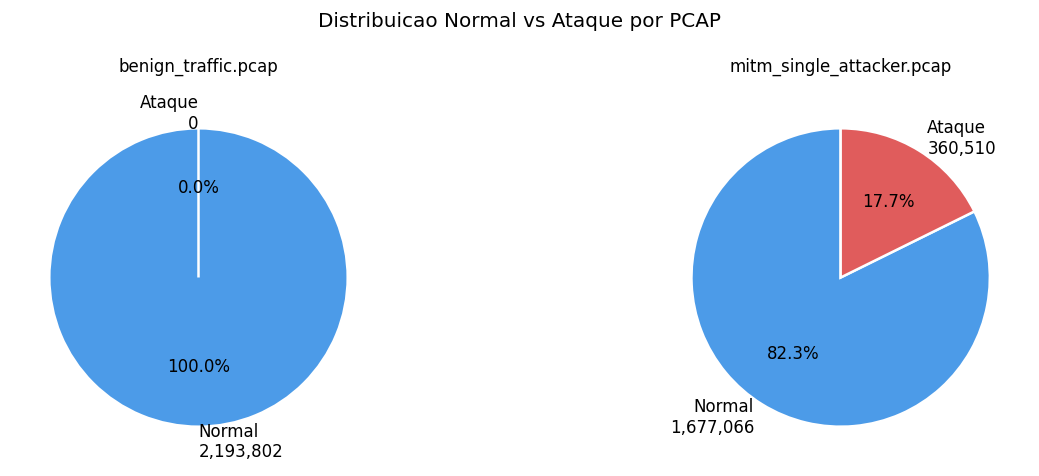

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, row in zip(axes, pcap_stats):
    vals   = [row['Normal (label=0)'], row['Ataque (label=1)']]
    colors = ['#4c9be8', '#e05c5c']
    labels = [f'Normal\n{vals[0]:,}', f'Ataque\n{vals[1]:,}']
    wedges, texts, autotexts = ax.pie(
        vals, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for at in autotexts:
        at.set_fontsize(10)
    ax.set_title(row['PCAP'], fontsize=10, pad=12)

plt.suptitle('Distribuicao Normal vs Ataque por PCAP', fontsize=12)
plt.tight_layout()
plt.savefig(MITM_DIR / 'pcap_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Extracao de Features

12 features comportamentais (mesma arquitetura do classificador MITM Multi).
Neste cenario, `f21_is_relay_service` sera sempre 0 (sem service_id=0x100B);
os discriminadores principais sao `f19_is_sd` e `f20_src_service_diversity`:

| Feature | Descricao | Sinal MITM Single |
|---------|----------|-----------------|
| f01 | ip_time_interval | — |
| f08 | someip_payload_change — Hamming entre payloads | Depende das notificacoes forjadas |
| f11 | ip_length_change | — |
| f12 | tcpudp_length_change | — |
| f13 | payload_repeat_rate | Depende das notificacoes forjadas |
| f15 | someip_payload_len | Especifico do servico |
| f16 | tcpudp_len | — |
| f17 | src_packet_rate (janela 1000 pkts) | Elevado |
| f18 | src_payload_diversity (janela) | Depende das notificacoes |
| **f19** | **is_sd — 1 se service_id=0xFFFF** | **1** (comp. A, IP real) |
| **f20** | **src_service_diversity — servicos distintos (janela 100)** | **≥2** |
| f21 | is_relay_service — 1 se service_id=0x100B | **0** (sem relay) |

**Normalizacao**: Min-Max [0,1]. **Split**: 50/50 estratificado.

In [6]:
run_script(MITM_DIR / '01_features.py', cwd=DET_DIR)

Executando: C:\Users\Guilherme Frick\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe C:\Mestrado\SDV_Research\detection\mitm_single\01_features.py


### 3.1 Dataset consolidado

In [7]:
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy').astype(int)
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy').astype(int)

n_total = len(y_train) + len(y_test)
n_ben   = (y_train==0).sum() + (y_test==0).sum()
n_mitm  = (y_train==1).sum() + (y_test==1).sum()

split_data = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste', 'Total'],
    'Amostras': [len(y_train), len(y_test), n_total],
    'Normal':   [(y_train==0).sum(), (y_test==0).sum(), n_ben],
    'MITM':     [(y_train==1).sum(), (y_test==1).sum(), n_mitm],
    '% MITM':   [
        f'{100*(y_train==1).sum()/len(y_train):.1f}%',
        f'{100*(y_test==1).sum()/len(y_test):.1f}%',
        f'{100*n_mitm/n_total:.1f}%',
    ],
})
display(split_data.style.hide(axis='index'))
print(f'\nFeatures: {X_train.shape[1]}  |  Shape treino: {X_train.shape}  |  Shape teste: {X_test.shape}')

Conjunto,Amostras,Normal,MITM,% MITM
Treino,2115689,1935434,180255,8.5%
Teste,2115689,1935434,180255,8.5%
Total,4231378,3870868,360510,8.5%



Features: 12  |  Shape treino: (2115689, 12)  |  Shape teste: (2115689, 12)


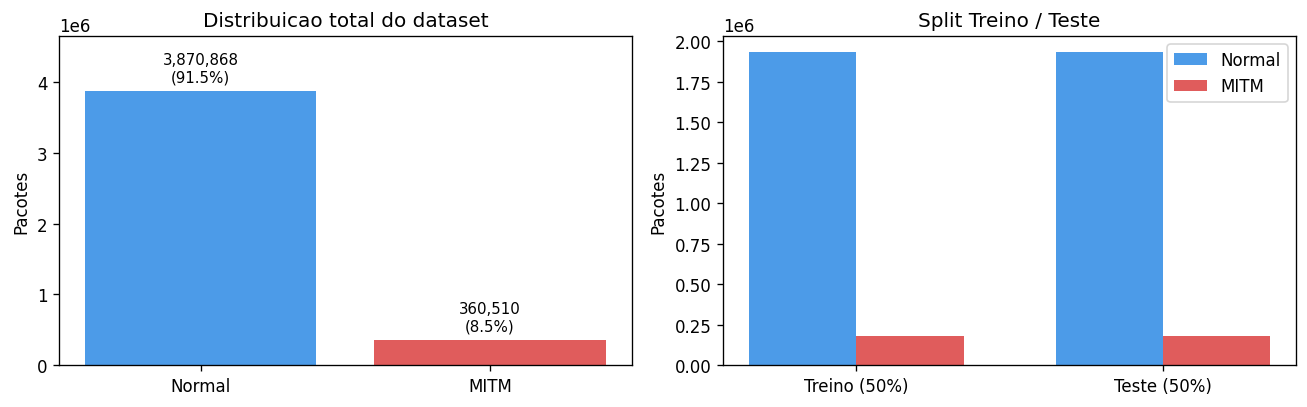

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(['Normal', 'MITM'], [n_ben, n_mitm], color=['#4c9be8','#e05c5c'])
axes[0].bar_label(axes[0].containers[0],
                  labels=[f'{n_ben:,}\n({100*n_ben/n_total:.1f}%)',
                          f'{n_mitm:,}\n({100*n_mitm/n_total:.1f}%)'],
                  padding=4, fontsize=9)
axes[0].set_title('Distribuicao total do dataset')
axes[0].set_ylabel('Pacotes')
axes[0].set_ylim(0, max(n_ben, n_mitm) * 1.2)

x = np.arange(2); w = 0.35
axes[1].bar(x - w/2, [(y_train==0).sum(), (y_test==0).sum()], w, label='Normal', color='#4c9be8')
axes[1].bar(x + w/2, [(y_train==1).sum(), (y_test==1).sum()], w, label='MITM',   color='#e05c5c')
axes[1].set_xticks(x); axes[1].set_xticklabels(['Treino (50%)', 'Teste (50%)'])
axes[1].set_title('Split Treino / Teste')
axes[1].set_ylabel('Pacotes')
axes[1].legend()

plt.tight_layout()
plt.savefig(MITM_DIR / 'dataset_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Treinamento

**Algoritmo**: XGBoost, classificacao binaria.  
**Parametros**: `n_estimators=100`, `max_depth=6`, `learning_rate=0.3`, `tree_method=hist`.

In [9]:
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.3,
    subsample=1.0, colsample_bytree=1.0,
    tree_method='hist', eval_metric='logloss',
    random_state=42, n_jobs=-1,
)

t0 = time.perf_counter()
model.fit(X_train, y_train, verbose=False)
t_train = time.perf_counter() - t0

single = X_test[:1]
_ = model.predict(single)
t0 = time.perf_counter()
for _ in range(1000):
    model.predict(single)
t_single_ms = (time.perf_counter() - t0) / 1000 * 1000

t0 = time.perf_counter()
y_pred = model.predict(X_test)
t_batch = time.perf_counter() - t0
y_prob  = model.predict_proba(X_test)[:, 1]

MODEL_DIR.mkdir(exist_ok=True)
model.save_model(str(MODEL_DIR / 'mitm_single_classifier.json'))

print(f'Tempo de treinamento : {t_train:.2f} s')
print(f'Inferencia batch     : {t_batch:.3f} s  ({len(X_test):,} amostras)')
print(f'Latencia por pacote  : {t_single_ms:.3f} ms')
print(f'Throughput           : {len(X_test)/t_batch:,.0f} pkt/s')
print(f'Modelo salvo em      : {MODEL_DIR}/mitm_single_classifier.json')

Tempo de treinamento : 6.72 s
Inferencia batch     : 0.837 s  (2,115,689 amostras)
Latencia por pacote  : 0.628 ms
Throughput           : 2,528,994 pkt/s
Modelo salvo em      : C:\Mestrado\SDV_Research\detection\mitm_single\model/mitm_single_classifier.json


## 5. Metricas de Classificacao

In [10]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val = fp / (fp + tn)
fnr_val = fn / (fn + tp)

summary = pd.DataFrame({
    'Metrica': [
        'Acuracia', 'Precision', 'Recall (TPR)', 'F1-Score', 'AUC-ROC',
        'Verdadeiros Negativos (TN)', 'Falsos Positivos (FP)',
        'Falsos Negativos (FN)', 'Verdadeiros Positivos (TP)',
        'Taxa Falso Positivo (FPR)', 'Taxa Falso Negativo (FNR)',
        'Tempo de treinamento', 'Latencia por pacote', 'Throughput',
    ],
    'Valor': [
        f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}', f'{auc:.6f}',
        f'{tn:,}', f'{fp:,}', f'{fn:,}', f'{tp:,}',
        f'{fpr_val:.6f}', f'{fnr_val:.6f}',
        f'{t_train:.2f} s', f'{t_single_ms:.3f} ms', f'{len(X_test)/t_batch:,.0f} pkt/s',
    ]
})
display(summary.style.hide(axis='index'))

Metrica,Valor
Acuracia,0.9999
Precision,0.9997
Recall (TPR),0.9991
F1-Score,0.9994
AUC-ROC,1.000000
Verdadeiros Negativos (TN),"1,935,384"
Falsos Positivos (FP),50
Falsos Negativos (FN),157
Verdadeiros Positivos (TP),"180,098"
Taxa Falso Positivo (FPR),0.000026


## 6. Visualizacoes

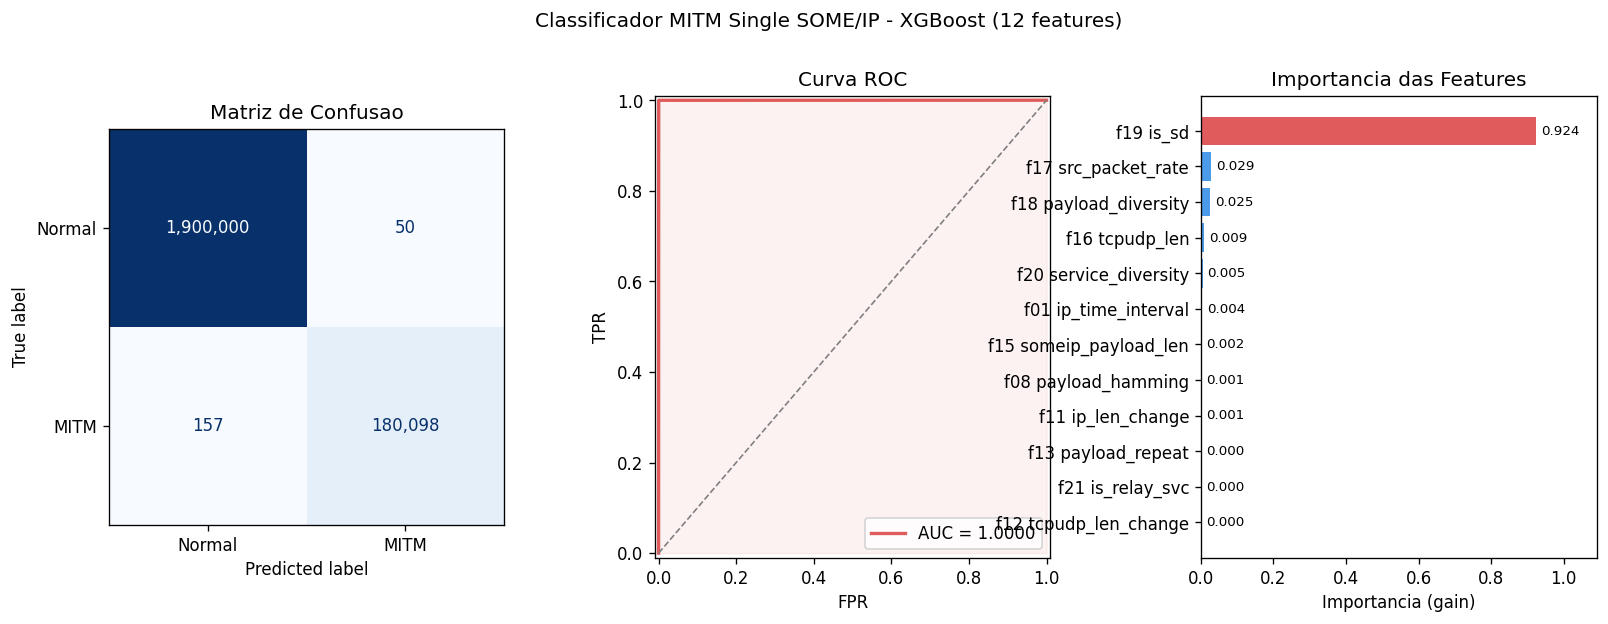

In [11]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

ax0 = fig.add_subplot(gs[0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'MITM'])
disp.plot(ax=ax0, colorbar=False, cmap='Blues')
ax0.set_title('Matriz de Confusao')
for text in disp.text_.ravel():
    v = int(float(text.get_text()))
    text.set_text(f'{v:,}')

ax1 = fig.add_subplot(gs[1])
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr_c, tpr_c, lw=2, color='#e05c5c', label=f'AUC = {auc:.4f}')
ax1.fill_between(fpr_c, tpr_c, alpha=0.08, color='#e05c5c')
ax1.plot([0,1],[0,1],'--', color='grey', lw=1)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Curva ROC')
ax1.legend(loc='lower right')
ax1.set_xlim(-0.01, 1.01); ax1.set_ylim(-0.01, 1.01)

ax2 = fig.add_subplot(gs[2])
imps  = model.feature_importances_
order = np.argsort(imps)
colors = ['#e05c5c' if imps[i] > 0.05 else '#4c9be8' for i in order]
bars = ax2.barh([FEAT_LABELS[i] for i in order], imps[order], color=colors)
ax2.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax2.set_xlabel('Importancia (gain)')
ax2.set_title('Importancia das Features')
ax2.set_xlim(0, max(imps) * 1.18)

plt.suptitle('Classificador MITM Single SOME/IP - XGBoost (12 features)', fontsize=12, y=1.02)
plt.savefig(MITM_DIR / 'results_overview.png', bbox_inches='tight', dpi=150)
plt.show()

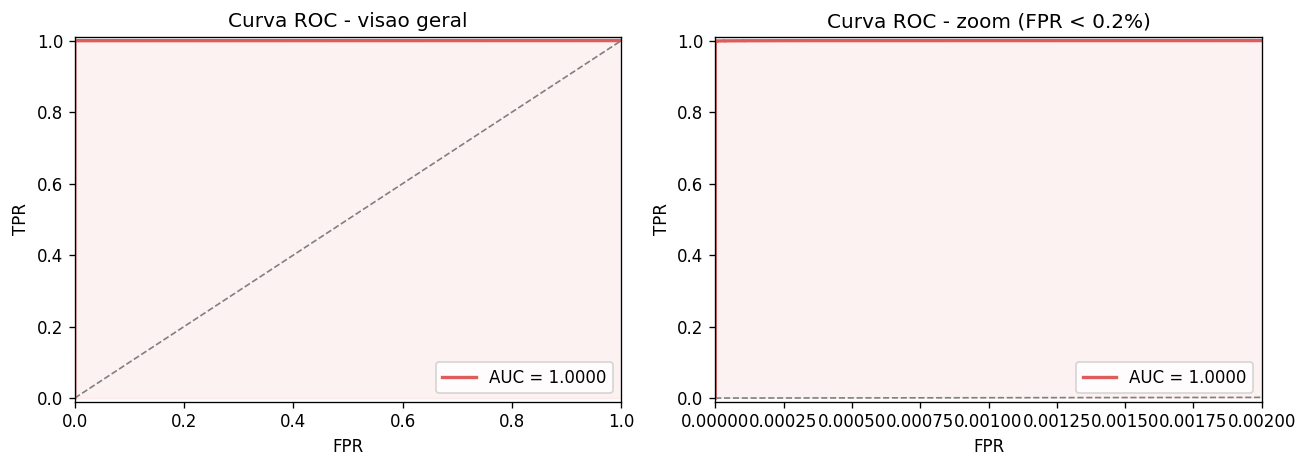

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, xlim, title in zip(axes,
                            [(0, 1), (0, 0.002)],
                            ['Curva ROC - visao geral', 'Curva ROC - zoom (FPR < 0.2%)']):
    ax.plot(fpr_c, tpr_c, lw=2, color='#e05c5c', label=f'AUC = {auc:.4f}')
    ax.fill_between(fpr_c, tpr_c, alpha=0.08, color='#e05c5c')
    ax.plot([0,1],[0,1],'--', color='grey', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title); ax.legend(loc='lower right')
    ax.set_xlim(xlim); ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig(MITM_DIR / 'roc_detail.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Discussao

### Desempenho e Features

Ao contrario do `mitm_multi_attacker`, este cenario nao possui a componente de relay
(service_id=0x100B), tornando-o significativamente mais sutil. A deteccao depende de
features comportamentais de segunda ordem:

- **f19 is_sd**: o atacante envia SD Withdraw com seu proprio IP (172.18.0.13),
  portanto estes pacotes sao rotulados como ataque e treinam o classificador a
  associar `is_sd=1` (especialmente com TTL=0 implicito nos padroes SD) ao comportamento
  do atacante.
- **f20 src_service_diversity**: o atacante opera em dois service_ids distintos
  (0xFFFF para SD e 0x1001 para forged notifications), gerando diversity ≥ 2.
  ECUs normais tipicamente publicam em um unico servico.
- **f17 src_packet_rate**: a combinacao SD + ADAS forjado gera uma taxa de
  transmissao mais alta que o comportamento benigno tipico.

### Comparacao com MITM Multi

| Aspecto | MITM Multi | MITM Single |
|---------|-----------|-------------|
| Feature dominante | f21 (68.7%) | f19/f20/f17 |
| Facilidade de deteccao | Alta (relay service anomalo) | Moderada (sem discriminador obvio) |
| Evasao possivel | Mudar service_id do relay | Mais dificil de evadir |

### Limitacoes

| Cenario | Detectado? | Motivo |
|---------|-----------|--------|
| SD Withdraw + ADAS injection (este dataset) | Sim | f19 + f20 discriminam |
| Atacante com apenas forged notifications (sem SD) | Nao | f19=0; depende apenas de f17/f18 |
| Atacante que usa um unico service_id (0x1001) | Parcial | f20=1; comportamento similar ao DoS |
| SD Withdraw com IP spoofado (como no multi) | Nao | label=0 no parser; f19 nao treinado |

Este classificador e complementar ao MITM Multi: juntos cobrem tanto o ataque sofisticado
com relay quanto o ataque mais simples de SD disruption + impersonation.